## Experimental code for NSW

In [22]:
import numpy as np 
import matplotlib.pyplot as plt 

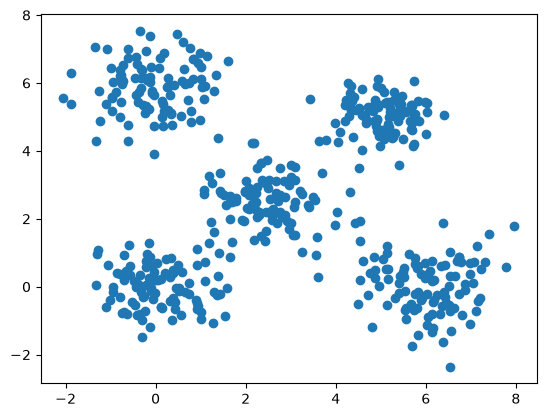

In [23]:
np.random.seed(93)

cluster1 = np.random.randn(100, 2) * 0.67 + np.array([0, 0])
cluster2 = np.random.randn(100, 2) * 0.59 + np.array([5, 5])
cluster3 = np.random.randn(100, 2) * 0.8 + np.array([0, 6])
cluster4 = np.random.randn(100, 2) * 0.78 + np.array([6, 0])
cluster0 = np.random.randn(100, 2) * 0.77 + np.array([2.5, 2.5])

X = np.vstack([
    cluster0, 
    cluster1,
    cluster2,
    cluster3,
    cluster4
])

plt.scatter(X[:, 0], X[:, 1])
plt.show()


In [28]:
import heapq


def distance_metric(x, y): 
    return np.linalg.norm(x - y)


def KNN_search(graph, X, idx, k , m): 
    '''  
        graph : It is the graph data structure we are building
        X : the matix contaning the data vectors 
        k : the parameter k of KNN
        m : the number of times, we run the algorithm 
    '''
    rng = np.random.default_rng()
    result = []
    visitedSet = set()
        
    for i in range(m): 
        tempRes = []
        candidates = []
            
        rstar_pt = rng.choice(range(0, len(graph)))
        d = distance_metric(X[rstar_pt], X[idx])
        
        heapq.heappush(candidates, (d, rstar_pt))
        visitedSet.add(idx) # this is query point, will change in generic search implementation
        visitedSet.add(rstar_pt)
        
        while candidates: 
            distc, c = heapq.heappop(candidates)
            
            # check stopping condition here 
            if len(result) >= k:
                pdist, pnode = result[k-1]
                if distc > pdist: 
                    break 
            
            for n in graph[c]: 
                if n not in visitedSet: 
                    visitedSet.add(n)
                    tempRes.append(n)
                    dist = distance_metric(X[n], X[idx])
                    heapq.heappush(candidates, (dist, n))
        
        for e in tempRes:
            dd = distance_metric(X[e], X[idx])
            result.append((dd, e))
        
        unique_results = {}
        for dist, node in result:
            if node not in unique_results or dist < unique_results[node]:
                unique_results[node] = dist
        
        result = sorted([(d, n) for n, d in unique_results.items()], key=lambda x: x[0])

    return [node for dist, node in result[:k]]


def insert(graph, X, idx, k, m):
    # handling the base case 
    if len(graph) == 0:
        graph[idx] = [] 
        return graph 
    
    if len(graph) < k: 
        nbrs = list(graph.keys())
    else: 
        nbrs = KNN_search(graph, X, idx, k, m)
    
    graph[idx] = nbrs 
    
    for j in nbrs: 
        graph[j].append(idx)

    return graph 


def build_NSW(X, k=3, m=3):
    graph = {}
    
    for i in range(len(X)):
        graph = insert(graph, X, i, k, m) 

    return graph 

In [31]:
graph = build_NSW(X)

In [32]:
# Visualizing the graph 
def plot_graph(X, graph):
    plt.figure(figsize=(10, 10))

    # Draw points
    plt.scatter(X[:, 0], X[:, 1])

    # Draw edges
    for i, neighbors in graph.items():
        for j in neighbors:
            plt.plot(
                [X[i, 0], X[j, 0]],
                [X[i, 1], X[j, 1]],
                alpha=0.5
            )

    plt.show()

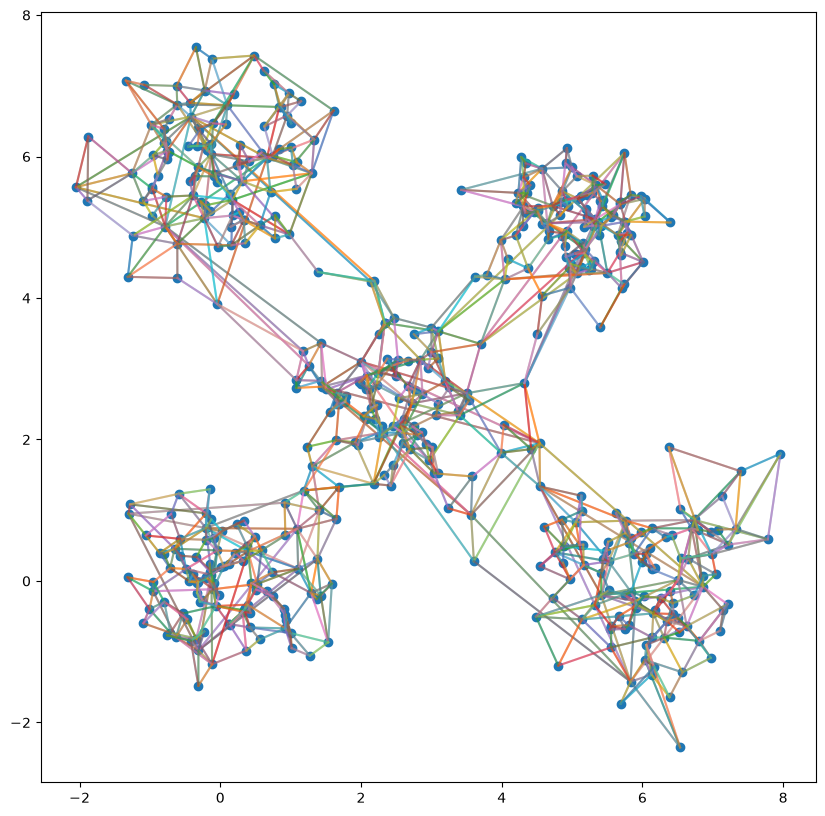

In [33]:
plot_graph(X, graph=graph)

In [ ]:
# Writing the specialized search code. To search for a query 

def ANN_search(graph, X, query, k=1 , m=3): 
    '''  
        graph : It is the graph data structure we are building
        X : the matix contaning the data vectors 
        k : the parameter k of KNN
        m : the number of times, we run the algorithm 
    '''
    rng = np.random.default_rng()
    result = []
    visitedSet = set()
        
    for i in range(m): 
        tempRes = []
        candidates = []
            
        rstar_pt = rng.choice(range(0, len(graph)))
        d = distance_metric(X[rstar_pt], query)
        
        heapq.heappush(candidates, (d, rstar_pt))
        visitedSet.add(rstar_pt)
        
        while candidates: 
            distc, c = heapq.heappop(candidates)
            
            # check stopping condition here 
            if len(result) >= k:
                pdist, pnode = result[k-1]
                if distc > pdist: 
                    break 
            
            for n in graph[c]: 
                if n not in visitedSet: 
                    visitedSet.add(n)
                    tempRes.append(n)
                    dist = distance_metric(X[n], query)
                    heapq.heappush(candidates, (dist, n))
        
        for e in tempRes:
            dd = distance_metric(X[e], query)
            result.append((dd, e))
        
        unique_results = {}
        for dist, node in result:
            if node not in unique_results or dist < unique_results[node]:
                unique_results[node] = dist
        
        result = sorted([(d, n) for n, d in unique_results.items()], key=lambda x: x[0])

    return [node for dist, node in result[:k]]


q = [1.0, 5.0]
Vec = X[*ANN_search(graph, X, q)]


# lets find the actual nearest neighbour
def exact_search(X, query):
    distances = np.linalg.norm(X - query, axis=1)
    return np.argmin(distances)

enn = X[exact_search(X, q)]


array([0.98197372, 4.89830922])

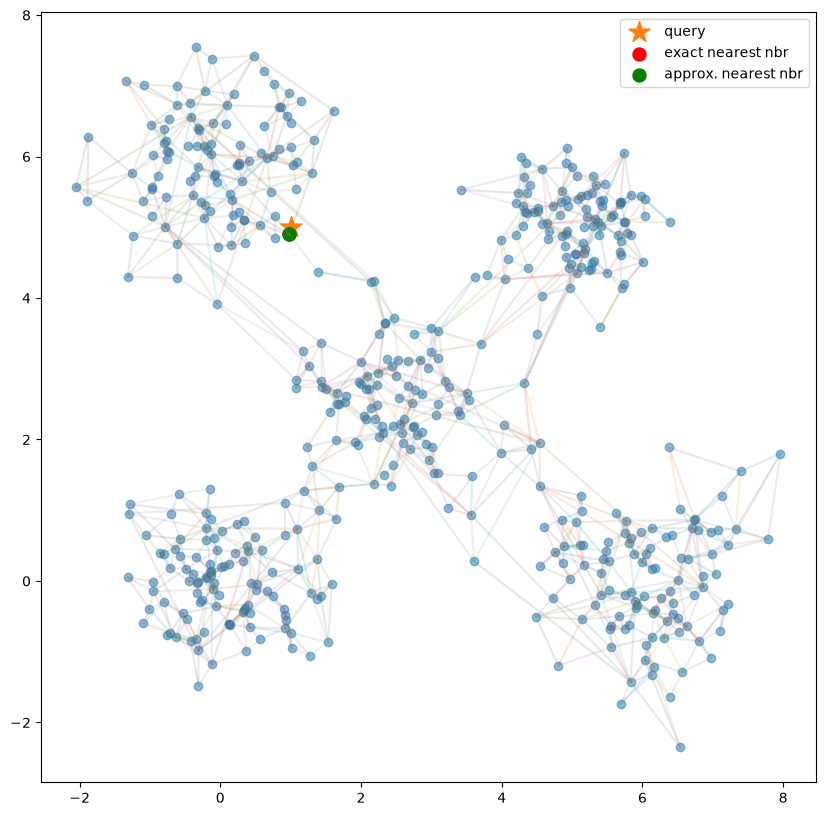

In [37]:
def plot_search(X, graph, query, exact_nn, ann):

    plt.figure(figsize=(10, 10))

    # Graph
    for i, neighbors in graph.items():
        for j in neighbors:
            plt.plot(
                [X[i, 0], X[j, 0]],
                [X[i, 1], X[j, 1]],
                alpha=0.08
            )

    # All points
    plt.scatter(
        X[:, 0],
        X[:, 1],
        alpha=0.5
    )

    # Query
    plt.scatter(
        query[0],
        query[1],
        marker="*",
        s=250, 
        label = 'query'
    )

    plt.scatter(
        exact_nn[0],
        exact_nn[1], 
        marker = '.', 
        s = 350, 
        c = 'r', 
        label='exact nearest nbr'
    )
        
    plt.scatter(
        ann[0],
        ann[1], 
        marker = '.', 
        s = 350, 
        c = 'g', 
        label='approx. nearest nbr'
    )
    
    plt.legend()    
    plt.show() 
    
    
plot_search(X, graph=graph, query=q, exact_nn=enn, ann=Vec)

In [38]:
def recall_at_k(graph, X, n_queries=500, k=1, m=1, seed=0):
    rng = np.random.default_rng(seed)
    lo, hi = X.min(0), X.max(0)
    Q = rng.uniform(lo, hi, size=(n_queries, X.shape[1]))
    hits = 0
    for q in Q:
        exact = set(np.argsort(np.linalg.norm(X - q, axis=1))[:k])
        approx = set(ANN_search(graph, X, q, k=k, m=m))
        hits += len(exact & approx) / k
    return hits / n_queries

for k in [2, 4, 8, 16, 32]:
    print(k, recall_at_k(graph, X, k=k, m=3))

2 0.997
4 0.9975
8 0.997
16 0.998
32 0.99825
